In [1]:
import csv
import matplotlib.pyplot as plt
import os
import re
import shutil

shutil.rmtree('./results', ignore_errors=True)

In [ ]:
%%bash
python fast_sampling_device_study.py --device cuda --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500 --split
python fast_sampling_device_study.py --device cpu --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500 --split
python fast_sampling_device_study.py --device cuda --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500
python fast_sampling_device_study.py --device cpu --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500

ERROR! Session/line number was not unique in database. History logging moved to new session 203
Default device: [CudaDevice(id=0)]


Running sampling with 1 chains...

	Using sampler: split RNG
	Sampler selection completed in 4.16e-06 seconds.

	Preparation completed in 3.47e-01 seconds.
	Warm-up sampling completed in 6.60e-01 seconds.
		Sampling completed in 6.01e-01 seconds.
	Timing recorded in 8.37e-02 seconds.
	All 1 trials completed.
	Mean and std computed in 1.25e-01 seconds.

	**Total time for sampling with 1 chains: 1.82 seconds.**

	Appending times completed in 1.67e-06 seconds.


Running sampling with 501 chains...

	Using sampler: split RNG
	Sampler selection completed in 3.11e-06 seconds.

	Preparation completed in 2.24e-01 seconds.
	Warm-up sampling completed in 6.82e-01 seconds.
		Sampling completed in 6.68e-01 seconds.
	Timing recorded in 1.19e-03 seconds.
	All 1 trials completed.
	Mean and std computed in 4.90e-04 seconds.

	**Total time for sampling with 501 chains: 1.

Traceback (most recent call last):
  File "/home/pfargas/Desktop/PhD/qvarnet/scripts/fast_sampling_device_study.py", line 224, in <module>
    mean_time, std_time = time_run_sampling_split(
                          ~~~~~~~~~~~~~~~~~~~~~~~^
        n_chain,
        ^^^^^^^^
        number_of_steps_per_chain,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^
        n_trials=N_TRIALS,
        ^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/pfargas/Desktop/PhD/qvarnet/scripts/fast_sampling_device_study.py", line 186, in time_run_sampling_split
    result = sampler_split(init_keys, n_steps, prob_fn, init_positions)
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/jax/_src/traceback_util.py", line 180, in reraise_with_filtered_traceback
    return fun(*args, **kwargs)
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/jax/_src/api.py", line 1112, in vmap_f
    out_flat = batching.batch(
        flat_fun, axis_data, in_axes_flat,
        lambda: flatt

TypeError: %d format: a real number is required, not NoneType

TypeError: %d format: a real number is required, not NoneType

Reading file: ./results/cuda/times_with_10000_split_False.csv
Reading file: ./results/cpu/times_with_10000_split_False.csv


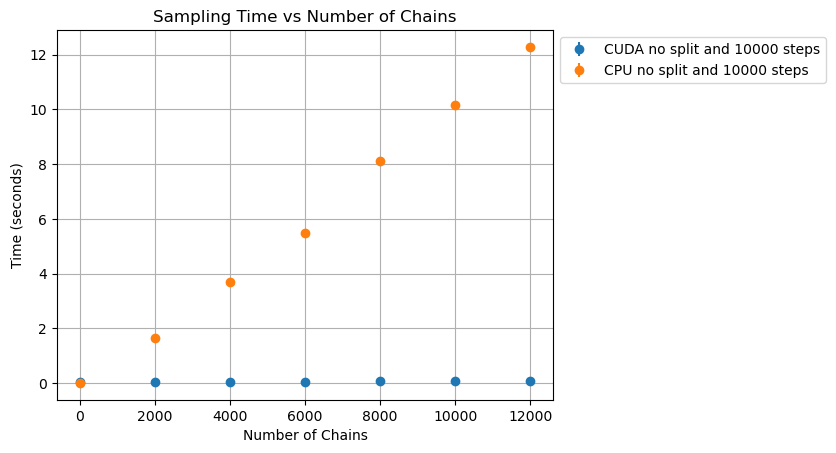

In [ ]:
def extract_info_from_filename(filename):
    match = re.search(r"times_with_(\d+)_split_(True|False)", filename)
    if match:
        n_chains = int(match.group(1))
        split = match.group(2) == "True"
        return n_chains, split
    return None

def read_files(device):
    files = os.listdir(f"./results/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Chains":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

times_cuda = read_files("cuda")
times_cpu = read_files("cpu")

def plot_from_times_dict(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} steps"
        plt.errorbar(
            [x[0] for x in value['data']],
            [x[1] for x in value['data']],
            yerr=[x[2] for x in value['data']],
            fmt='o',
            label=label
        )

plot_from_times_dict(times_cuda, 'CUDA')
plot_from_times_dict(times_cpu, 'CPU')


plt.xlabel('Number of Chains')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Chains')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)

plt.grid(True)